# Language Localizer GLM — Individual Top-10% Binary Masks

For each subject:
1. Fit a first-level GLM on the language localizer (S vs N).
2. Compute the S > N contrast (effect-size map).
3. Resample the language parcels atlas into BOLD space.
4. Within each parcel, keep only the top 10 % of voxels (by effect size) → binary mask.
5. Save per-parcel masks and a combined all-parcel mask.

In [7]:
import os
import json
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt

from nilearn.glm.first_level import FirstLevelModel
from nilearn.plotting import plot_design_matrix, plot_stat_map, plot_roi
from nilearn.image import resample_to_img, new_img_like

In [8]:
# ── Configuration ────────────────────────────────────────────
subjects = ["sub-001", "sub-002", "sub-003", "sub-004"]

base_dir   = "/usr/people/zt4569/neu502b/neu502b_fmri/final_proj_localizer"
mask_dir   = "/usr/people/zt4569/neu502b/neu502b_fmri/localizer_masks"

LANG_PARCEL = os.path.join(base_dir, "allParcels-language-SN220.nii")

# The original atlas has 12 parcels (6 LH + 6 RH).
ROI_MAPS = {
    1: 'LH_IFGorb',  2: 'LH_IFG',     3: 'LH_MFG',
    4: 'LH_AntTemp',  5: 'LH_PostTemp', 6: 'LH_AnG',
    7: 'RH_IFGorb',  8: 'RH_IFG',     9: 'RH_MFG',
   10: 'RH_AntTemp', 11: 'RH_PostTemp', 12: 'RH_AnG',
}

TOP_PERCENT = 10

print(f"Base directory : {base_dir}")
print(f"Parcels file   : {LANG_PARCEL}")
print(f"Subjects       : {subjects}")

Base directory : /usr/people/zt4569/neu502b/neu502b_fmri/final_proj_localizer
Parcels file   : /usr/people/zt4569/neu502b/neu502b_fmri/final_proj_localizer/allParcels-language-SN220.nii
Subjects       : ['sub-001', 'sub-002', 'sub-003', 'sub-004']


In [9]:
# ── Helper: build file paths for one subject ─────────────────
def get_subject_paths(subject):
    prefix = f"{subject}_ses-01_task-langXlocal_run-1"
    return {
        "bold":      os.path.join(base_dir,
                        f"{prefix}_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz"),
        "mask":      os.path.join(base_dir,
                        f"{prefix}_space-MNI152NLin2009cAsym_desc-brain_mask.nii.gz"),
        "confounds": os.path.join(base_dir,
                        f"{prefix}_desc-confounds_timeseries.tsv"),
        "events":    os.path.join(base_dir, "langloc_events.tsv"),
    }

In [10]:
# ── Helper: load confound regressors ─────────────────────────
def load_confounds(confounds_path, n_scans):
    df = pd.read_csv(confounds_path, sep="\t")

    motion = ["trans_x", "trans_y", "trans_z",
              "rot_x",   "rot_y",   "rot_z"]
    acomp  = sorted([c for c in df.columns if c.startswith("a_comp_cor")])[:5]

    cols = [c for c in motion if c in df.columns] + \
           [c for c in acomp  if c in df.columns]

    if "framewise_displacement" in df.columns:
        cols.append("framewise_displacement")

    if not cols:
        raise ValueError("No usable confound columns found.")

    out = df[cols].copy().fillna(0)
    if len(out) != n_scans:
        raise ValueError(
            f"Confounds rows ({len(out)}) != n_scans ({n_scans}).")
    return out

In [11]:
# ── Helper: top-10% binary mask within each parcel ───────────
#
# KEY FIX vs. original code:
#   1. We resample the parcels atlas to the effect-map grid
#      INSIDE this function (nearest-neighbour), so shapes
#      always match.
#   2. We iterate over the individual integer parcel labels
#      (1-12), NOT over a collapsed binary mask.  The original
#      code collapsed all parcels into a single binary mask
#      (0/1) before thresholding, which merged all 12 parcels
#      into one giant region and picked the top 10% across
#      ALL of them — not within each parcel.
#   3. We use the proper affine from the effect-map image
#      when saving the NIfTI, instead of a hardcoded 2-mm
#      MNI affine that didn't match the data grid.
#   4. The binarisation step no longer mutates the thresholded
#      array in-place (which corrupted the combined mask in
#      the original code).

def make_froi_masks(effect_map_nii, parcels_nii, subject,
                    top_pct=10, roi_maps=None, export_root=None):
    """
    For each parcel, keep the top *top_pct* % of voxels by
    effect size, binarise, and save.

    Returns the combined binary mask as a Nifti1Image.
    """
    # ── resample parcels into effect-map space ───────────────
    parcels_res_nii = resample_to_img(
        source_img=parcels_nii,
        target_img=effect_map_nii,
        interpolation='nearest',
        force_resample=True,
    )
    parc_data = np.asarray(parcels_res_nii.dataobj)
    eff_data  = effect_map_nii.get_fdata()

    assert parc_data.shape == eff_data.shape, (
        f"Shape mismatch after resampling: "
        f"parcels {parc_data.shape} vs effect {eff_data.shape}")

    # ── prepare export directory ─────────────────────────────
    export_path = os.path.join(export_root, subject)
    os.makedirs(export_path, exist_ok=True)

    ref_affine = effect_map_nii.affine
    ref_header = effect_map_nii.header

    combined_mask = np.zeros(eff_data.shape, dtype=np.int16)

    parcel_ids = np.unique(parc_data)
    parcel_ids = parcel_ids[parcel_ids != 0]  # drop background

    print(f"  Parcel IDs found after resampling: {parcel_ids}")

    for pid in parcel_ids:
        pid_int = int(pid)
        idx = parc_data == pid          # boolean mask for this parcel
        vals = eff_data[idx]

        if len(vals) == 0:
            print(f"  Parcel {pid_int}: empty after resampling — skipped")
            continue

        thr = np.percentile(vals, 100 - top_pct)
        keep = idx & (eff_data >= thr)    # voxels that survive

        # per-parcel binary mask
        parcel_mask = np.zeros(eff_data.shape, dtype=np.int16)
        parcel_mask[keep] = 1

        # add to the combined mask
        combined_mask[keep] = 1

        # save per-parcel mask
        label = roi_maps.get(pid_int, f"parcel_{pid_int}") if roi_maps else f"parcel_{pid_int}"
        fname = os.path.join(export_path,
                             f"{label}_fROI_mask_binary_top{top_pct}percent")
        nib.save(nib.Nifti1Image(parcel_mask, ref_affine, ref_header),
                 f"{fname}.nii.gz")

        n_kept = int(parcel_mask.sum())
        print(f"  Parcel {pid_int:2d} ({label:14s}): "
              f"{len(vals):5d} voxels, thr={thr:.4f}, "
              f"kept {n_kept}")

    # save combined mask
    combined_fname = os.path.join(
        export_path, f"ALL_fROI_mask_binary_top{top_pct}percent")
    combined_nii = nib.Nifti1Image(combined_mask, ref_affine, ref_header)
    nib.save(combined_nii, f"{combined_fname}.nii.gz")

    print(f"  Combined mask voxels: {int(combined_mask.sum())}")
    print(f"  Saved combined mask  -> {combined_fname}.nii.gz")

    return combined_nii

In [12]:
# ── Load language parcels atlas (once) ───────────────────────
parcels_nii = nib.load(LANG_PARCEL)
print(f"Parcels shape : {parcels_nii.shape}")
print(f"Parcel IDs    : {np.unique(parcels_nii.get_fdata())}")

Parcels shape : (91, 109, 91)
Parcel IDs    : [ 0.  1.  2.  3.  4.  5.  7.  8.  9. 10. 11.]



  sub-001
  BOLD shape : (78, 93, 78, 189)
  n_scans    : 189
  TR         : 2
  Trial types: ['S', 'N']
  Confounds  : 12 regressors
  Design-matrix columns: ['N', 'S', 'trans_x', 'trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z', 'a_comp_cor_00', 'a_comp_cor_01', 'a_comp_cor_02', 'a_comp_cor_03', 'a_comp_cor_04', 'framewise_displacement', 'drift_1', 'drift_2', 'drift_3', 'drift_4', 'drift_5', 'constant']


/tmp/ipykernel_1743039/3774156914.py:52: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


  Saved design matrix  -> /usr/people/zt4569/neu502b/neu502b_fmri/final_proj_localizer/sub-001_design_matrix.png
  Saved t-map          -> /usr/people/zt4569/neu502b/neu502b_fmri/final_proj_localizer/sub-001_S_minus_N_tmap.nii.gz
  Saved effect map     -> /usr/people/zt4569/neu502b/neu502b_fmri/final_proj_localizer/sub-001_S_minus_N_effect.nii.gz
  Saved stat map PNG   -> /usr/people/zt4569/neu502b/neu502b_fmri/final_proj_localizer/sub-001_S_minus_N_tmap.png
  Parcel IDs found after resampling: [ 1.  2.  3.  4.  5.  7.  8.  9. 10. 11.]
  Parcel  1 (LH_IFGorb     ):   191 voxels, thr=0.1259, kept 20
  Parcel  2 (LH_IFG        ):   366 voxels, thr=0.3726, kept 37
  Parcel  3 (LH_MFG        ):   219 voxels, thr=0.3235, kept 22
  Parcel  4 (LH_AntTemp    ):   834 voxels, thr=0.4264, kept 84
  Parcel  5 (LH_PostTemp   ):  1503 voxels, thr=0.4985, kept 151
  Parcel  7 (RH_IFGorb     ):   186 voxels, thr=0.2004, kept 19
  Parcel  8 (RH_IFG        ):   373 voxels, thr=0.4754, kept 38
  Parcel 

<Figure size 1400x600 with 0 Axes>

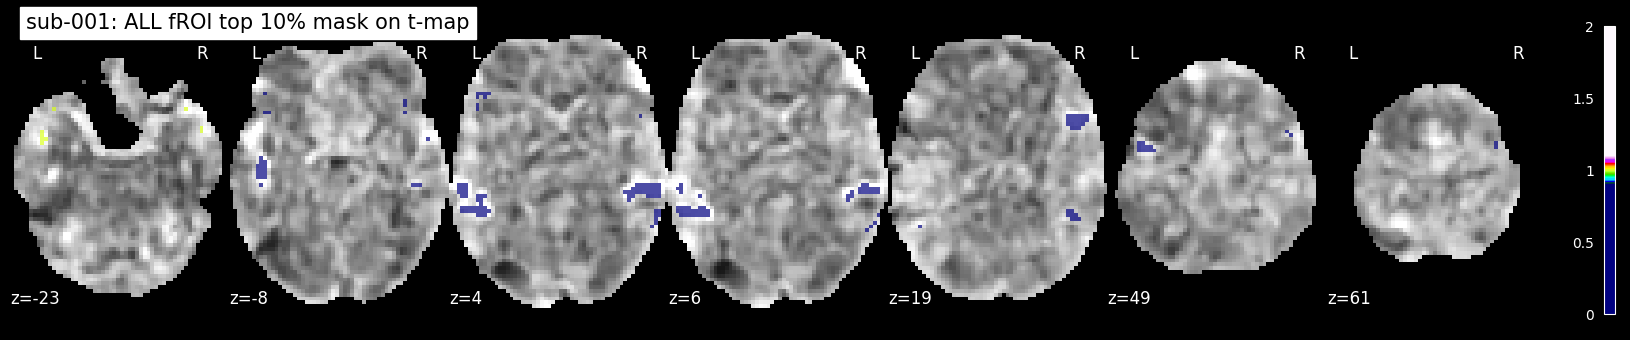


  sub-002
  BOLD shape : (78, 93, 78, 180)
  n_scans    : 180
  TR         : 2
  Trial types: ['S', 'N']
  Confounds  : 12 regressors
  Design-matrix columns: ['N', 'S', 'trans_x', 'trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z', 'a_comp_cor_00', 'a_comp_cor_01', 'a_comp_cor_02', 'a_comp_cor_03', 'a_comp_cor_04', 'framewise_displacement', 'drift_1', 'drift_2', 'drift_3', 'drift_4', 'drift_5', 'constant']


/tmp/ipykernel_1743039/3774156914.py:52: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


  Saved design matrix  -> /usr/people/zt4569/neu502b/neu502b_fmri/final_proj_localizer/sub-002_design_matrix.png
  Saved t-map          -> /usr/people/zt4569/neu502b/neu502b_fmri/final_proj_localizer/sub-002_S_minus_N_tmap.nii.gz
  Saved effect map     -> /usr/people/zt4569/neu502b/neu502b_fmri/final_proj_localizer/sub-002_S_minus_N_effect.nii.gz
  Saved stat map PNG   -> /usr/people/zt4569/neu502b/neu502b_fmri/final_proj_localizer/sub-002_S_minus_N_tmap.png
  Parcel IDs found after resampling: [ 1.  2.  3.  4.  5.  7.  8.  9. 10. 11.]
  Parcel  1 (LH_IFGorb     ):   191 voxels, thr=0.6757, kept 20
  Parcel  2 (LH_IFG        ):   366 voxels, thr=0.5643, kept 37
  Parcel  3 (LH_MFG        ):   219 voxels, thr=0.4772, kept 22
  Parcel  4 (LH_AntTemp    ):   834 voxels, thr=0.5480, kept 84
  Parcel  5 (LH_PostTemp   ):  1503 voxels, thr=0.7188, kept 151
  Parcel  7 (RH_IFGorb     ):   186 voxels, thr=0.2903, kept 19
  Parcel  8 (RH_IFG        ):   373 voxels, thr=0.2732, kept 38
  Parcel 

<Figure size 1400x600 with 0 Axes>

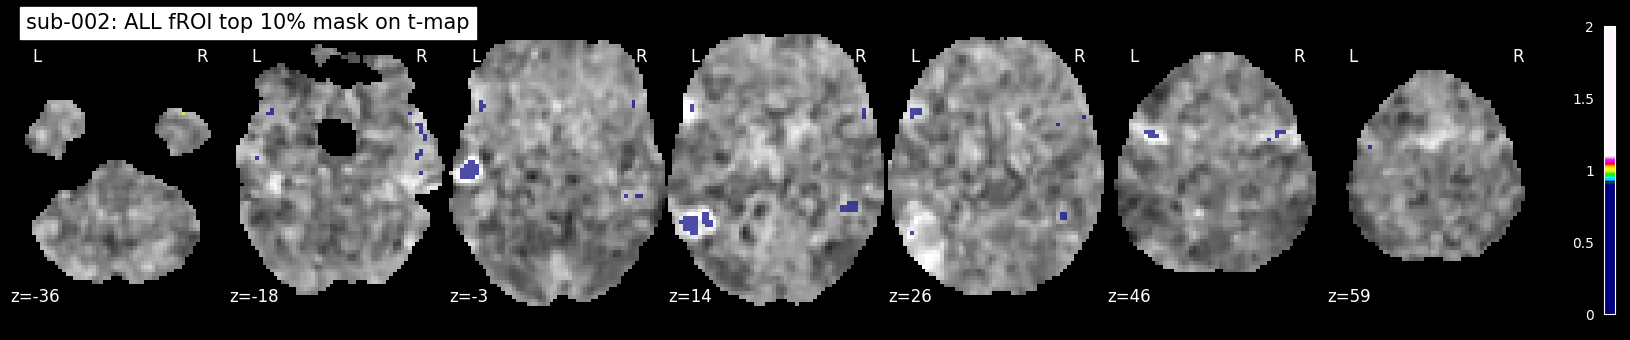


  sub-003
  BOLD shape : (78, 93, 78, 181)
  n_scans    : 181
  TR         : 2
  Trial types: ['S', 'N']
  Confounds  : 12 regressors
  Design-matrix columns: ['N', 'S', 'trans_x', 'trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z', 'a_comp_cor_00', 'a_comp_cor_01', 'a_comp_cor_02', 'a_comp_cor_03', 'a_comp_cor_04', 'framewise_displacement', 'drift_1', 'drift_2', 'drift_3', 'drift_4', 'drift_5', 'constant']


/tmp/ipykernel_1743039/3774156914.py:52: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


  Saved design matrix  -> /usr/people/zt4569/neu502b/neu502b_fmri/final_proj_localizer/sub-003_design_matrix.png
  Saved t-map          -> /usr/people/zt4569/neu502b/neu502b_fmri/final_proj_localizer/sub-003_S_minus_N_tmap.nii.gz
  Saved effect map     -> /usr/people/zt4569/neu502b/neu502b_fmri/final_proj_localizer/sub-003_S_minus_N_effect.nii.gz
  Saved stat map PNG   -> /usr/people/zt4569/neu502b/neu502b_fmri/final_proj_localizer/sub-003_S_minus_N_tmap.png
  Parcel IDs found after resampling: [ 1.  2.  3.  4.  5.  7.  8.  9. 10. 11.]
  Parcel  1 (LH_IFGorb     ):   191 voxels, thr=0.1527, kept 20
  Parcel  2 (LH_IFG        ):   366 voxels, thr=0.1785, kept 37
  Parcel  3 (LH_MFG        ):   219 voxels, thr=0.3514, kept 22
  Parcel  4 (LH_AntTemp    ):   834 voxels, thr=0.5255, kept 84
  Parcel  5 (LH_PostTemp   ):  1503 voxels, thr=0.5662, kept 151
  Parcel  7 (RH_IFGorb     ):   186 voxels, thr=0.1962, kept 19
  Parcel  8 (RH_IFG        ):   373 voxels, thr=0.0319, kept 38
  Parcel 

/usr/people/es2277/miniconda3/envs/neu502b/lib/python3.12/site-packages/numpy/ma/core.py:2896: UserWarning: Warning: converting a masked element to nan.
  _data = np.array(data, dtype=dtype, copy=copy,


<Figure size 1400x600 with 0 Axes>

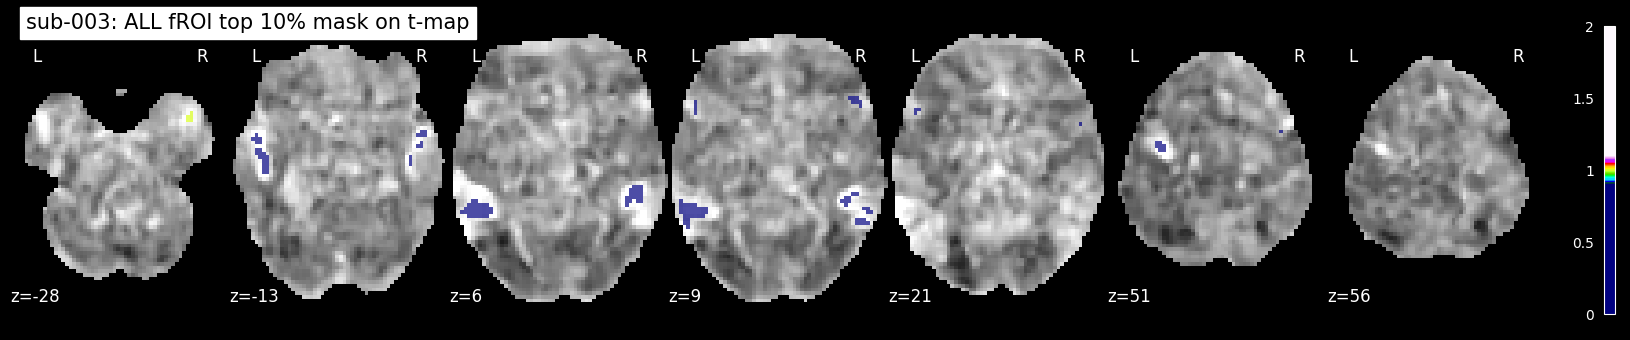


  sub-004
  BOLD shape : (78, 93, 78, 179)
  n_scans    : 179
  TR         : 2
  Trial types: ['S', 'N']
  Confounds  : 12 regressors
  Design-matrix columns: ['N', 'S', 'trans_x', 'trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z', 'a_comp_cor_00', 'a_comp_cor_01', 'a_comp_cor_02', 'a_comp_cor_03', 'a_comp_cor_04', 'framewise_displacement', 'drift_1', 'drift_2', 'drift_3', 'drift_4', 'drift_5', 'constant']


/tmp/ipykernel_1743039/3774156914.py:52: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


  Saved design matrix  -> /usr/people/zt4569/neu502b/neu502b_fmri/final_proj_localizer/sub-004_design_matrix.png
  Saved t-map          -> /usr/people/zt4569/neu502b/neu502b_fmri/final_proj_localizer/sub-004_S_minus_N_tmap.nii.gz
  Saved effect map     -> /usr/people/zt4569/neu502b/neu502b_fmri/final_proj_localizer/sub-004_S_minus_N_effect.nii.gz
  Saved stat map PNG   -> /usr/people/zt4569/neu502b/neu502b_fmri/final_proj_localizer/sub-004_S_minus_N_tmap.png
  Parcel IDs found after resampling: [ 1.  2.  3.  4.  5.  7.  8.  9. 10. 11.]
  Parcel  1 (LH_IFGorb     ):   191 voxels, thr=0.1828, kept 20
  Parcel  2 (LH_IFG        ):   366 voxels, thr=0.1385, kept 37
  Parcel  3 (LH_MFG        ):   219 voxels, thr=0.1896, kept 22
  Parcel  4 (LH_AntTemp    ):   834 voxels, thr=0.2816, kept 84
  Parcel  5 (LH_PostTemp   ):  1503 voxels, thr=0.4817, kept 151
  Parcel  7 (RH_IFGorb     ):   186 voxels, thr=0.1322, kept 19
  Parcel  8 (RH_IFG        ):   373 voxels, thr=0.0695, kept 38
  Parcel 

/usr/people/es2277/miniconda3/envs/neu502b/lib/python3.12/site-packages/numpy/ma/core.py:2896: UserWarning: Warning: converting a masked element to nan.
  _data = np.array(data, dtype=dtype, copy=copy,


<Figure size 1400x600 with 0 Axes>

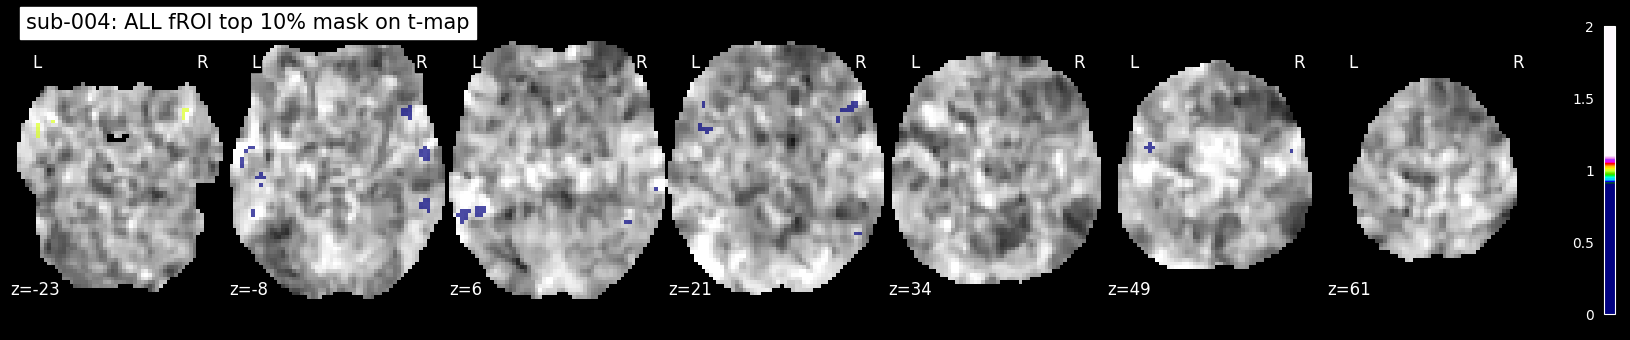


  All subjects done.


In [15]:
# ── Main loop: GLM + mask for every subject ──────────────────
for subject in subjects:
    print("\n" + "=" * 60)
    print(f"  {subject}")
    print("=" * 60)

    paths = get_subject_paths(subject)

    # ── 1. BOLD + TR ─────────────────────────────────────────
    bold_img = nib.load(paths["bold"])
    n_scans  = bold_img.shape[-1]
    tr = 2  # hardcoded TR as in original
    print(f"  BOLD shape : {bold_img.shape}")
    print(f"  n_scans    : {n_scans}")
    print(f"  TR         : {tr}")

    # ── 2. Events ────────────────────────────────────────────
    events_df = pd.read_csv(paths["events"], sep="\t")
    required = {"onset", "duration", "trial_type"}
    missing  = required - set(events_df.columns)
    if missing:
        raise ValueError(f"{subject}: events missing columns {missing}")
    print(f"  Trial types: {events_df['trial_type'].unique().tolist()}")

    # ── 3. Confounds ─────────────────────────────────────────
    confounds_use = load_confounds(paths["confounds"], n_scans)
    print(f"  Confounds  : {confounds_use.shape[1]} regressors")

    # ── 4. Fit first-level GLM ───────────────────────────────
    glm = FirstLevelModel(
        t_r=tr,
        mask_img=paths["mask"],
        noise_model="ar1",
        standardize=False,
        hrf_model="glover",
        drift_model="cosine",
        high_pass=1.0 / 128,
        smoothing_fwhm=5.0,
    )
    glm.fit(
        run_imgs=paths["bold"],
        events=events_df,
        confounds=confounds_use,
    )

    dm_cols = glm.design_matrices_[0].columns.tolist()
    print(f"  Design-matrix columns: {dm_cols}")

    # ── 5. Save design matrix plot ───────────────────────────
    plt.figure(figsize=(14, 6))
    plot_design_matrix(glm.design_matrices_[0])
    plt.tight_layout()
    dm_png = os.path.join(base_dir, f"{subject}_design_matrix.png")
    plt.savefig(dm_png, dpi=200, bbox_inches="tight")
    plt.close()
    print(f"  Saved design matrix  -> {dm_png}")

    # ── 6. Compute S > N contrast ────────────────────────────
    contrast_expr = "S - N"

    t_map      = glm.compute_contrast(contrast_expr, stat_type="t")
    effect_map = glm.compute_contrast(contrast_expr, output_type="effect_size")

    tmap_file   = os.path.join(base_dir, f"{subject}_S_minus_N_tmap.nii.gz")
    effect_file = os.path.join(base_dir, f"{subject}_S_minus_N_effect.nii.gz")
    t_map.to_filename(tmap_file)
    effect_map.to_filename(effect_file)
    print(f"  Saved t-map          -> {tmap_file}")
    print(f"  Saved effect map     -> {effect_file}")

    # ── 7. Stat-map visualisation ────────────────────────────
    display = plot_stat_map(
        t_map, threshold=3.1, display_mode="z",
        cut_coords=6, black_bg=False,
        title=f"{subject}: S > N",
    )
    stat_png = os.path.join(base_dir, f"{subject}_S_minus_N_tmap.png")
    display.savefig(stat_png, dpi=200)
    display.close()
    print(f"  Saved stat map PNG   -> {stat_png}")

    # ── 8. Generate top-10% binary mask within parcels ───────
    combined_mask_nii = make_froi_masks(
        effect_map_nii=effect_map,
        parcels_nii=parcels_nii,
        subject=subject,
        top_pct=TOP_PERCENT,
        roi_maps=ROI_MAPS,
        export_root=mask_dir,
    )

    # ── 9. Quick mask visualisation ──────────────────────────
    plot_roi(
        roi_img=combined_mask_nii,
        bg_img=t_map,
        title=f"{subject}: ALL fROI top {TOP_PERCENT}% mask on t-map",
        display_mode='z',
        black_bg=True,
        dim=-0.5,
        alpha=0.7,
    )
    plt.show()

print("\n" + "=" * 60)
print("  All subjects done.")
print("=" * 60)

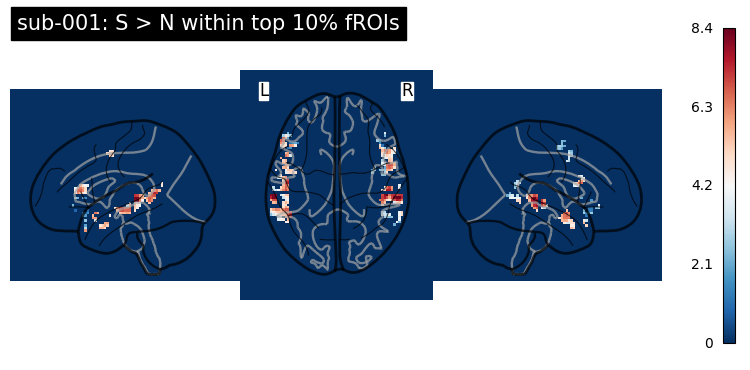

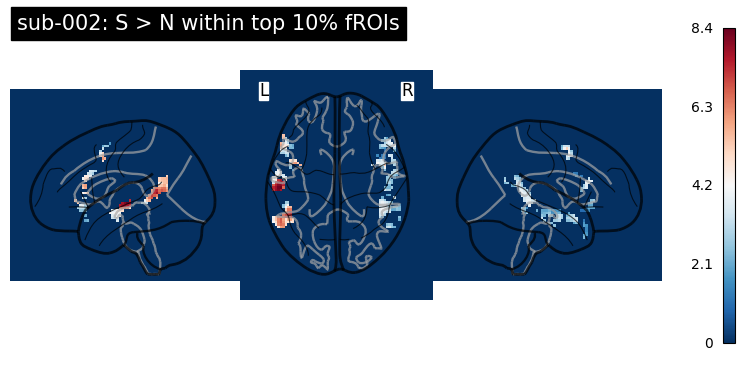

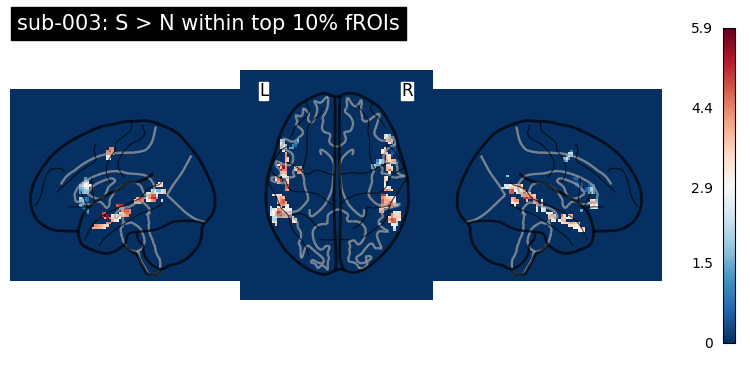

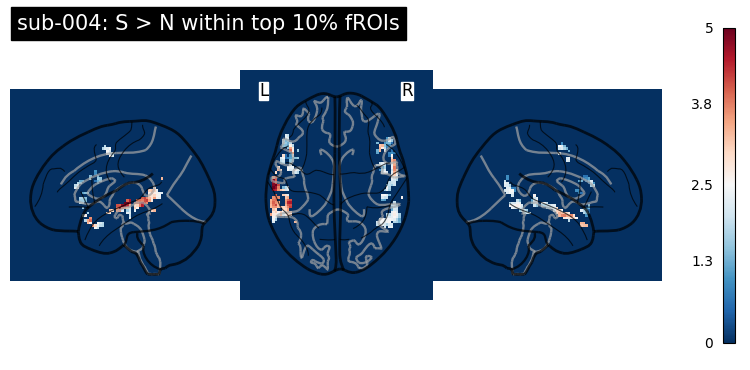

In [14]:
from nilearn.plotting import plot_glass_brain

for subject in subjects:
    # load the combined binary mask
    mask_path = os.path.join(
        mask_dir, subject,
        f"ALL_fROI_mask_binary_top{TOP_PERCENT}percent.nii.gz"
    )
    # load the t-map
    tmap_path = os.path.join(base_dir, f"{subject}_S_minus_N_tmap.nii.gz")

    t_map = nib.load(tmap_path)
    mask_nii = nib.load(mask_path)

    # mask the t-map: zero out everything outside the binary mask
    from nilearn.image import math_img
    masked_t = math_img("img1 * img2", img1=t_map, img2=mask_nii)

    plot_glass_brain(
        masked_t,
        colorbar=True,
        display_mode='lzr',
        plot_abs=False,
        title=f"{subject}: S > N within top {TOP_PERCENT}% fROIs",
    )
    plt.show()